In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [3]:
df.shape


(732, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [5]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [6]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [7]:
df['Sentiment'].value_counts()

Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

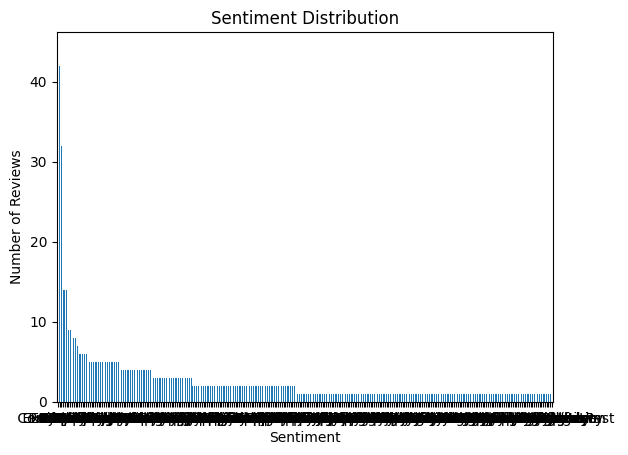

In [8]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [9]:
df = df.dropna(subset=['Text', 'Sentiment'])

In [10]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [11]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [12]:
X = df['Text']
y = df['Sentiment']

In [13]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
0     Enjoying a beautiful day at the park!        ...
1     Traffic was terrible this morning.           ...
2     Just finished an amazing workout! 💪          ...
3     Excited about the upcoming weekend getaway!  ...
4     Trying out a new recipe for dinner tonight.  ...
Name: Text, dtype: str

Target:
0     Positive  
1     Negative  
2     Positive  
3     Positive  
4     Neutral   
Name: Sentiment, dtype: str


In [14]:
print(y.unique())

<StringArray>
[   ' Positive  ',    ' Negative  ',    ' Neutral   ', ' Anger        ',
 ' Fear         ', ' Sadness      ', ' Disgust      ', ' Happiness    ',
 ' Joy          ', ' Love         ',
 ...
      ' Disgust ',       ' Relief ',     ' Positive ',  ' Embarrassed ',
  ' Mischievous ',          ' Sad ',         ' Hate ',          ' Bad ',
      ' Neutral ',        ' Happy ']
Length: 279, dtype: str


In [15]:
print(y.value_counts())

Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64


In [17]:
print(y.value_counts())

Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64


In [18]:
# Count the number of samples in each class
class_counts = y.value_counts()

# Classes having fewer than 5 samples
rare_classes = class_counts[class_counts < 5].index

# Replace rare classes with "Other"
y = y.replace(rare_classes, "Other")

# Check the new distribution
print(y.value_counts())

Sentiment
Other                402
 Positive             44
 Joy                  42
 Excitement           32
 Contentment          14
 Neutral              14
 Happy                14
 Hopeful               9
 Gratitude             9
 Sad                   9
 Curiosity             8
 Embarrassed           8
 Loneliness            7
 Elation               6
 Playful               6
 Despair               6
 Hate                  6
 Bad                   6
 Contentment           5
 Serenity              5
 Gratitude             5
 Empowerment           5
 Enthusiasm            5
 Curiosity             5
 Indifference          5
 Confusion             5
 Numbness              5
 Melancholy            5
 Nostalgia             5
 Ambivalence           5
 Acceptance            5
 Determination         5
 Serenity              5
 Inspired              5
 Bitterness            5
 Frustrated            5
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 585
Testing samples: 147


In [20]:
print("X:", len(X))
print("y:", len(y))

X: 732
y: 732


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (585, 2104)
Testing TF-IDF shape: (147, 2104)


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (585, 2104)
Testing TF-IDF shape: (147, 2104)


In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [26]:
y_pred_logistic = logistic_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_logistic, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_logistic, average='weighted', zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.5510204081632653
Precision: 0.3036234902124115
Recall   : 0.5510204081632653
F1 Score : 0.39151450053705694


In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0
))

                   precision    recall  f1-score   support

 Acceptance             0.00      0.00      0.00         1
 Ambivalence            0.00      0.00      0.00         1
             Bad        0.00      0.00      0.00         1
      Bitterness        0.00      0.00      0.00         1
 Confusion              0.00      0.00      0.00         1
     Contentment        0.00      0.00      0.00         3
   Contentment          0.00      0.00      0.00         1
       Curiosity        0.00      0.00      0.00         2
 Curiosity              0.00      0.00      0.00         1
         Despair        0.00      0.00      0.00         1
 Determination          0.00      0.00      0.00         1
   Elation              0.00      0.00      0.00         1
     Embarrassed        0.00      0.00      0.00         2
   Empowerment          0.00      0.00      0.00         1
   Enthusiasm           0.00      0.00      0.00         1
      Excitement        0.00      0.00      0.00       

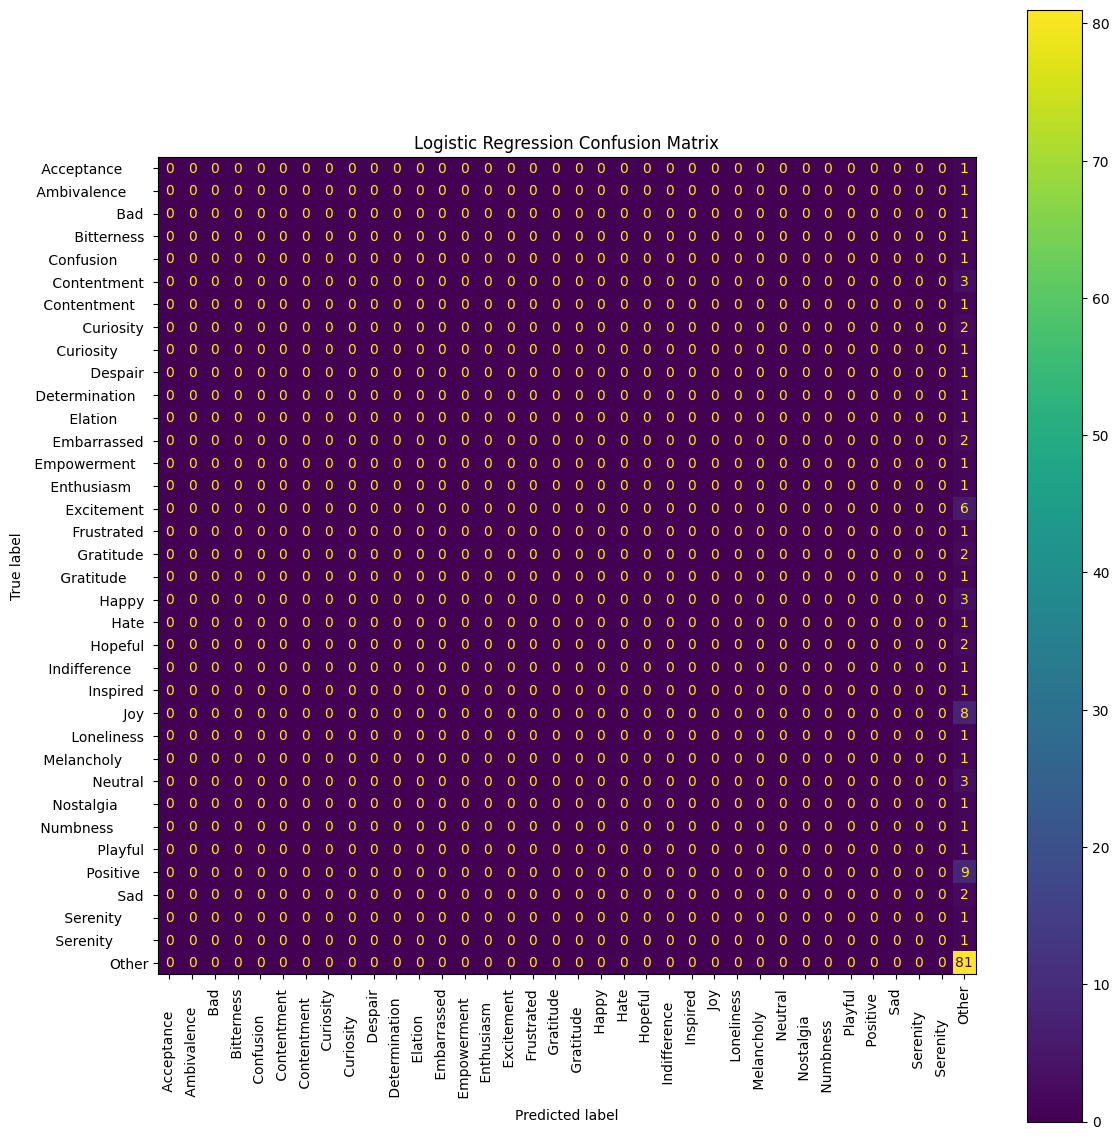

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20
)

decision_tree_model.fit(X_train_tfidf, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [32]:
y_pred_tree = decision_tree_model.predict(X_test_tfidf)

print("Decision Tree predictions completed!")

Decision Tree predictions completed!


In [33]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(
    y_test, y_pred_tree, average='weighted', zero_division=0
)
recall_tree = recall_score(
    y_test, y_pred_tree, average='weighted', zero_division=0
)
f1_tree = f1_score(
    y_test, y_pred_tree, average='weighted', zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1 Score :", f1_tree)

Decision Tree Results
---------------------
Accuracy : 0.6530612244897959
Precision: 0.5310460416050478
Recall   : 0.6530612244897959
F1 Score : 0.5710512357742679


In [34]:
print(classification_report(
    y_test,
    y_pred_tree,
    zero_division=0
))

                   precision    recall  f1-score   support

 Acceptance             0.00      0.00      0.00         1
 Ambivalence            1.00      1.00      1.00         1
             Bad        1.00      1.00      1.00         1
      Bitterness        1.00      1.00      1.00         1
 Confusion              0.00      0.00      0.00         1
     Contentment        1.00      0.67      0.80         3
   Contentment          1.00      1.00      1.00         1
       Curiosity        0.00      0.00      0.00         2
 Curiosity              1.00      1.00      1.00         1
         Despair        0.00      0.00      0.00         1
 Determination          0.50      1.00      0.67         1
   Elation              1.00      1.00      1.00         1
     Embarrassed        0.00      0.00      0.00         2
   Empowerment          0.00      0.00      0.00         1
   Enthusiasm           0.00      0.00      0.00         1
      Excitement        0.00      0.00      0.00       

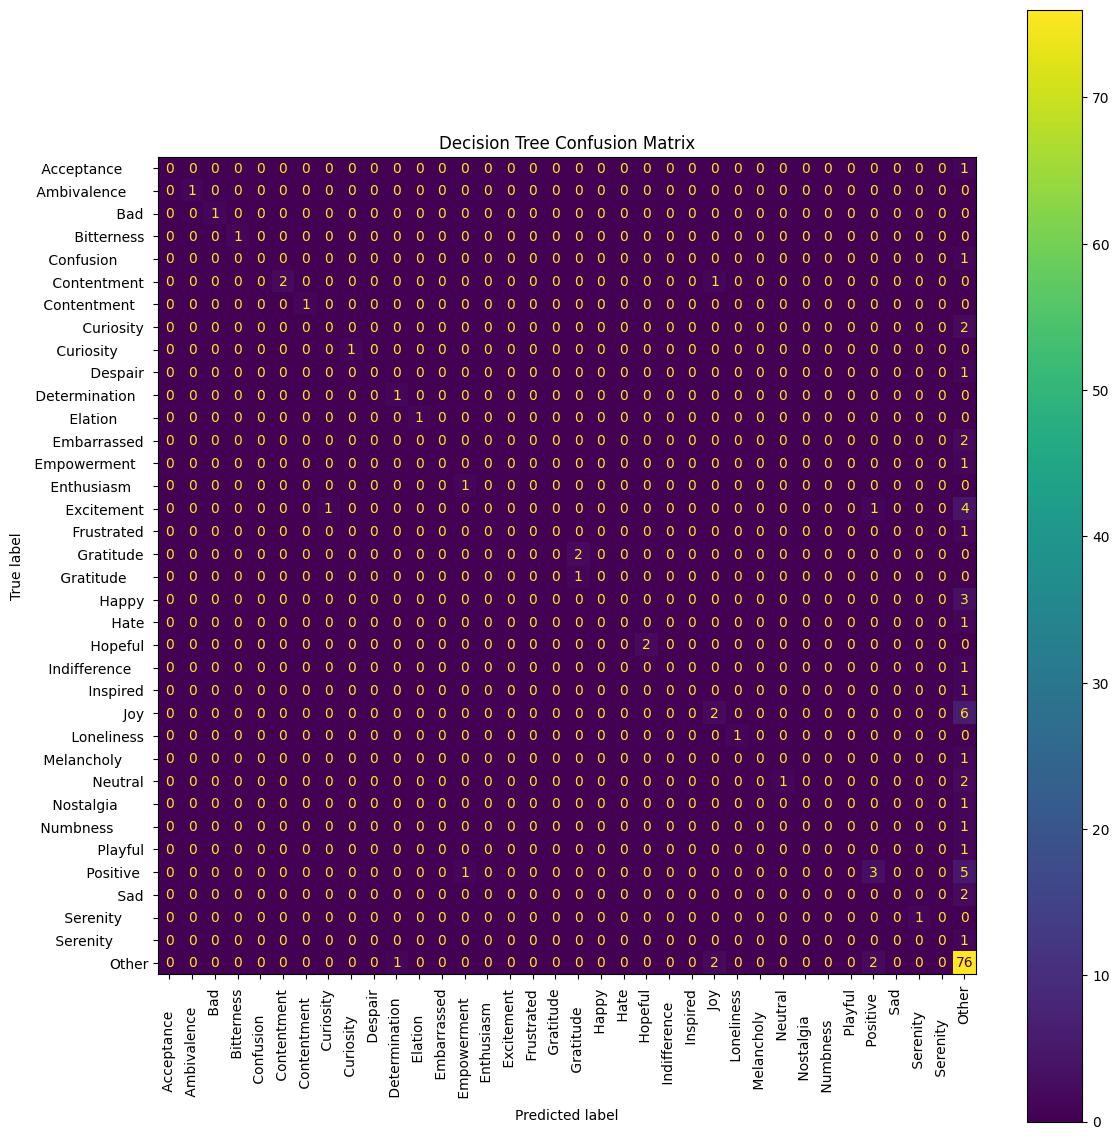

In [35]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=sorted(y.unique())
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [37]:
y_pred_rf = random_forest_model.predict(X_test_tfidf)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [38]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test, y_pred_rf,
    average='weighted',
    zero_division=0
)

recall_rf = recall_score(
    y_test, y_pred_rf,
    average='weighted',
    zero_division=0
)

f1_rf = f1_score(
    y_test, y_pred_rf,
    average='weighted',
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
---------------------
Accuracy : 0.6122448979591837
Precision: 0.49363335077620785
Recall   : 0.6122448979591837
F1 Score : 0.5210413169596844


In [39]:
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

                   precision    recall  f1-score   support

 Acceptance             1.00      1.00      1.00         1
 Ambivalence            1.00      1.00      1.00         1
             Bad        1.00      1.00      1.00         1
      Bitterness        0.00      0.00      0.00         1
 Confusion              0.00      0.00      0.00         1
     Contentment        1.00      0.33      0.50         3
   Contentment          0.50      1.00      0.67         1
       Curiosity        0.00      0.00      0.00         2
 Curiosity              0.00      0.00      0.00         1
         Despair        0.00      0.00      0.00         1
 Determination          0.50      1.00      0.67         1
   Elation              1.00      1.00      1.00         1
     Embarrassed        0.00      0.00      0.00         2
   Empowerment          0.00      0.00      0.00         1
   Enthusiasm           0.00      0.00      0.00         1
      Excitement        1.00      0.17      0.29       

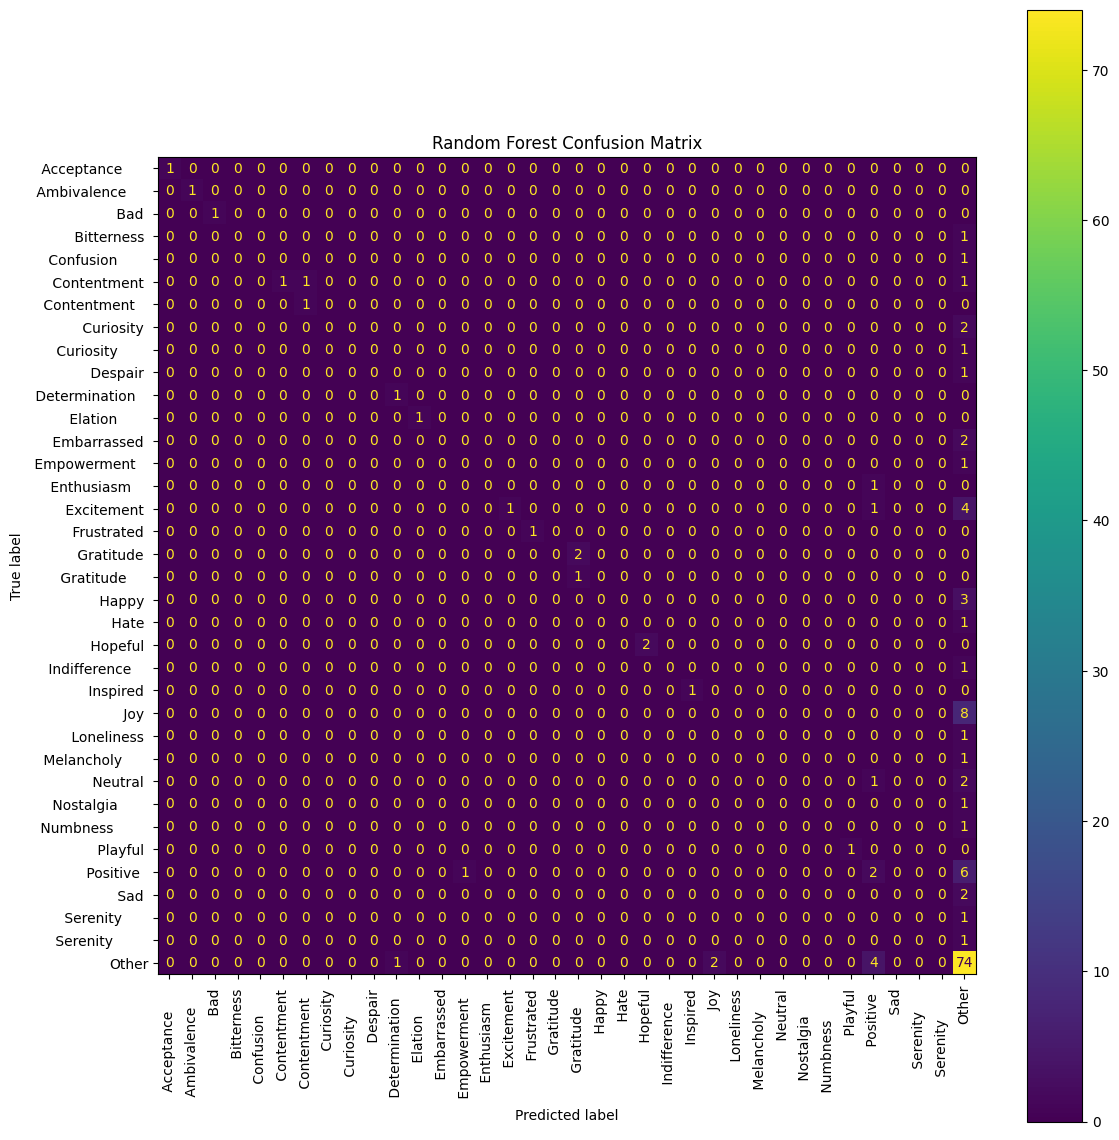

In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=sorted(y.unique())
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [46]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    'Precision': [
        precision,
        precision_tree,
        precision_rf
    ],
    'Recall': [
        recall,
        recall_tree,
        recall_rf
    ],
    'F1 Score': [
        f1,
        f1_tree,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.551020,0.303623,0.551020,0.391515
1,Decision Tree,0.653061,0.531046,0.653061,0.571051
2,Random Forest,0.612245,0.493633,0.612245,0.521041


In [47]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5510,0.3036,0.5510,0.3915
1,Decision Tree,0.6531,0.5310,0.6531,0.5711
2,Random Forest,0.6122,0.4936,0.6122,0.5210


In [48]:
best_model_name = results.loc[
    results['F1 Score'].idxmax(), 'Model'
]

best_f1_score = results['F1 Score'].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1_score)

Best Model: Decision Tree
Best F1 Score: 0.5710512357742679


In [49]:
results.to_csv("classification_results.csv", index=False)

print("Classification results saved successfully!")

Classification results saved successfully!


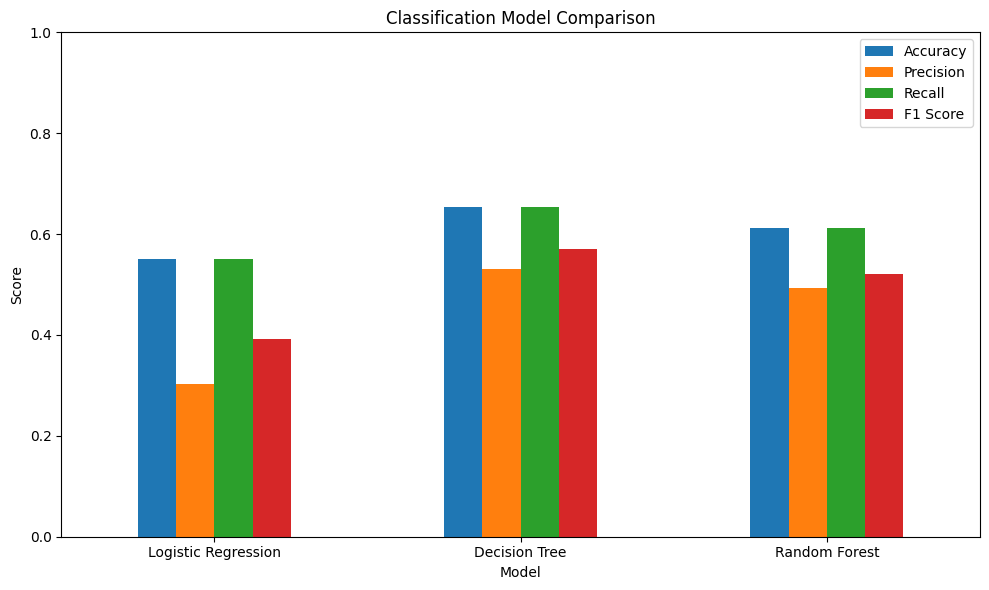

In [50]:
results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("Parameter grid created successfully!")

Parameter grid created successfully!


In [53]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [54]:
grid_search.fit(X_train_tfidf, y_train)

print("Grid Search completed successfully!")

Grid Search completed successfully!


In [55]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [56]:
print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)


Best Cross-Validation F1 Score:
0.4762995898457392


In [57]:
best_model = grid_search.best_estimator_

print("Best model obtained successfully!")

Best model obtained successfully!


In [58]:
y_pred_tuned = best_model.predict(X_test_tfidf)

print("Tuned model predictions completed!")

Tuned model predictions completed!


In [59]:
accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    average='weighted',
    zero_division=0
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    average='weighted',
    zero_division=0
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    average='weighted',
    zero_division=0
)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall   :", recall_tuned)
print("F1 Score :", f1_tuned)

Tuned Random Forest Results
---------------------------
Accuracy : 0.6122448979591837
Precision: 0.49363335077620785
Recall   : 0.6122448979591837
F1 Score : 0.5210413169596844


In [60]:
print(classification_report(
    y_test,
    y_pred_tuned,
    zero_division=0
))

                   precision    recall  f1-score   support

 Acceptance             1.00      1.00      1.00         1
 Ambivalence            1.00      1.00      1.00         1
             Bad        1.00      1.00      1.00         1
      Bitterness        0.00      0.00      0.00         1
 Confusion              0.00      0.00      0.00         1
     Contentment        1.00      0.33      0.50         3
   Contentment          0.50      1.00      0.67         1
       Curiosity        0.00      0.00      0.00         2
 Curiosity              0.00      0.00      0.00         1
         Despair        0.00      0.00      0.00         1
 Determination          0.50      1.00      0.67         1
   Elation              1.00      1.00      1.00         1
     Embarrassed        0.00      0.00      0.00         2
   Empowerment          0.00      0.00      0.00         1
   Enthusiasm           0.00      0.00      0.00         1
      Excitement        1.00      0.17      0.29       

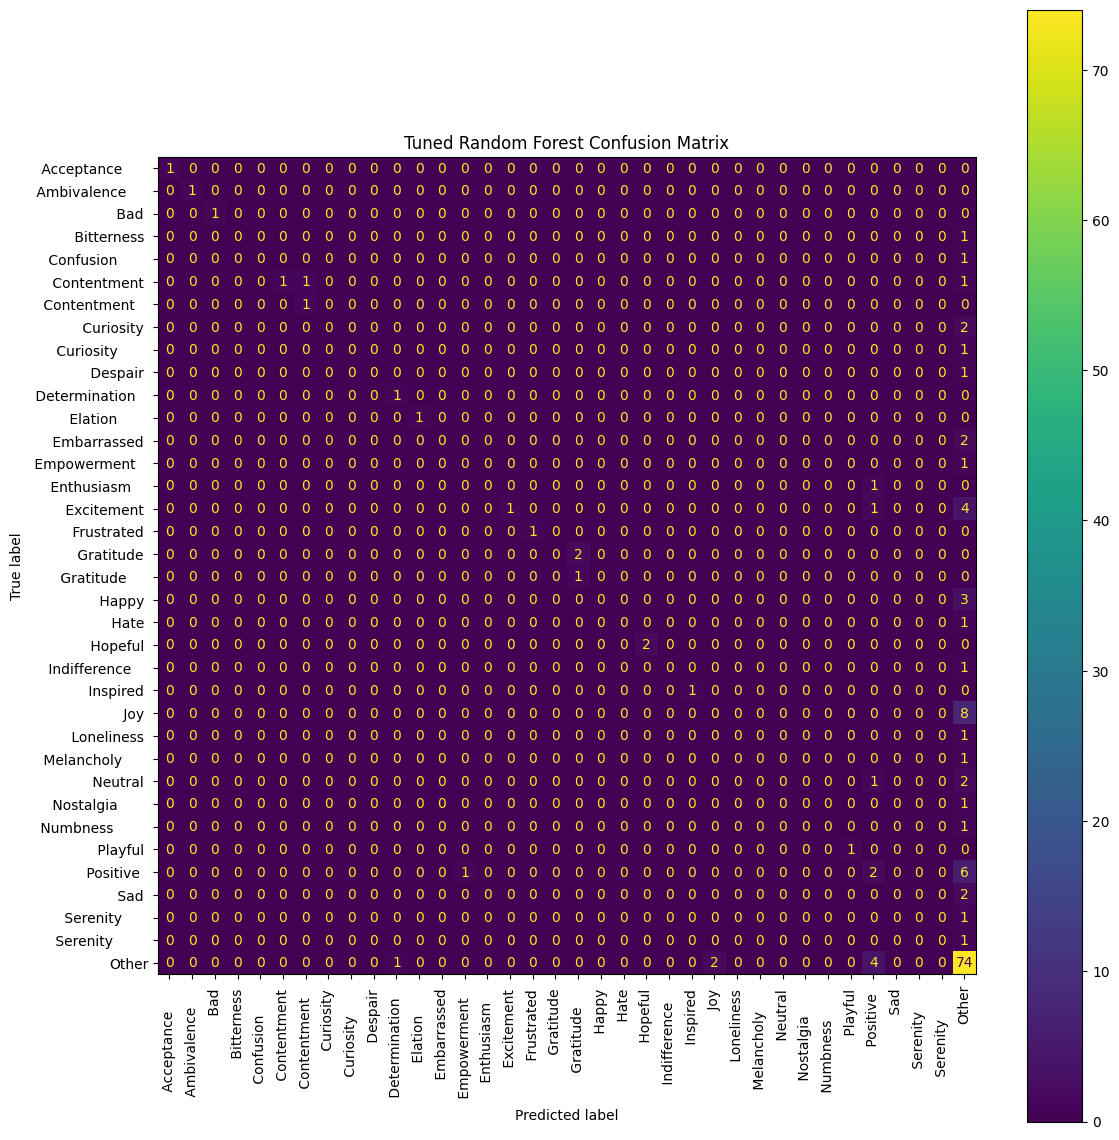

In [61]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=sorted(y.unique())
)

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "tuned_random_forest_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()



In [62]:
tuning_results = pd.DataFrame({
    'Model': [
        'Random Forest Before Tuning',
        'Random Forest After Tuning'
    ],
    'Accuracy': [
        accuracy_rf,
        accuracy_tuned
    ],
    'Precision': [
        precision_rf,
        precision_tuned
    ],
    'Recall': [
        recall_rf,
        recall_tuned
    ],
    'F1 Score': [
        f1_rf,
        f1_tuned
    ]
})

tuning_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest Before Tuning,0.6122,0.4936,0.6122,0.521
1,Random Forest After Tuning,0.6122,0.4936,0.6122,0.521


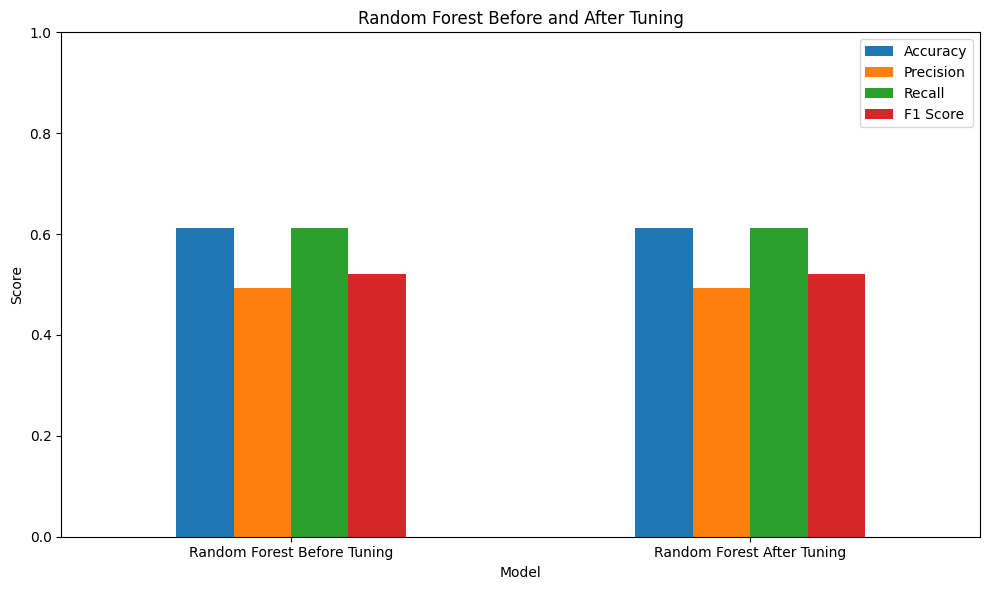

In [63]:
tuning_results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Random Forest Before and After Tuning")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "tuning_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [64]:
results.to_csv(
    "classification_results.csv",
    index=False
)

tuning_results.to_csv(
    "tuning_results.csv",
    index=False
)

print("All results saved successfully!")

All results saved successfully!


In [65]:
final_scores = {
    'Logistic Regression': f1,
    'Decision Tree': f1_tree,
    'Random Forest': f1_rf,
    'Tuned Random Forest': f1_tuned
}

best_final_model = max(
    final_scores,
    key=final_scores.get
)

print("Final Best Model:", best_final_model)
print("F1 Score:", final_scores[best_final_model])

Final Best Model: Decision Tree
F1 Score: 0.5710512357742679


In [66]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tree,
        accuracy_rf,
        accuracy_tuned
    ],
    'Precision': [
        precision,
        precision_tree,
        precision_rf,
        precision_tuned
    ],
    'Recall': [
        recall,
        recall_tree,
        recall_rf,
        recall_tuned
    ],
    'F1 Score': [
        f1,
        f1_tree,
        f1_rf,
        f1_tuned
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5510,0.3036,0.5510,0.3915
1,Decision Tree,0.6531,0.5310,0.6531,0.5711
2,Random Forest,0.6122,0.4936,0.6122,0.5210
3,Tuned Random Forest,0.6122,0.4936,0.6122,0.5210


In [67]:
final_results.to_csv(
    "final_classification_results.csv",
    index=False
)

print("Final results saved!")

Final results saved!


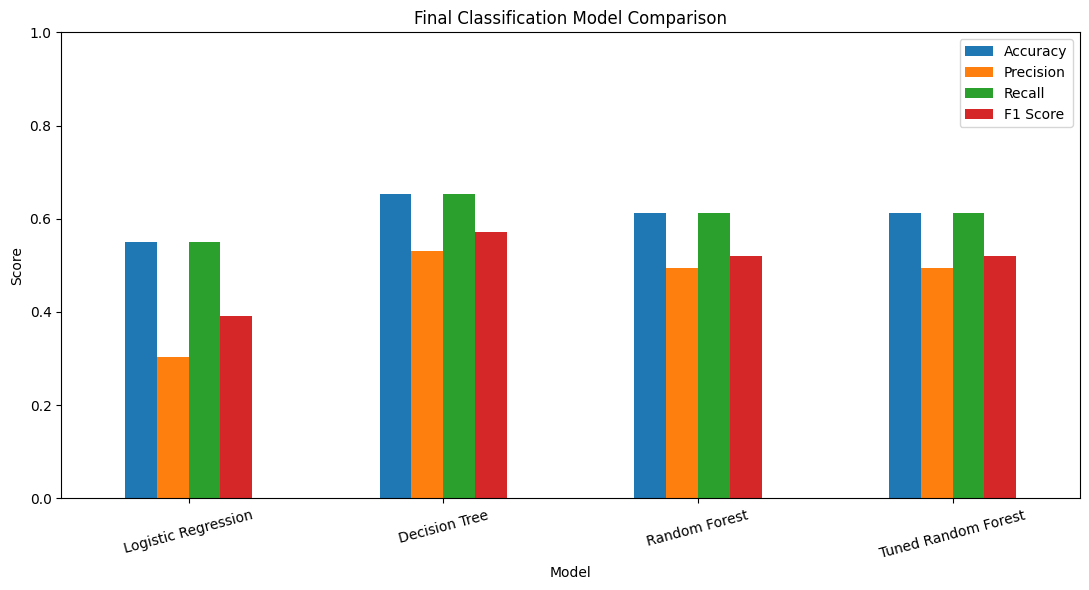

In [68]:
final_results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title("Final Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "final_model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()